In [1]:
import os
import re
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
STAT_PATH = "../experiments"
CLIENTS_DYNAMIC_NAME = os.path.join("exp", "clients_dynamic")
PARAMS_NAME = "parameters.xml"
EXP_NAME = "run"


In [3]:
def read_total_clients(params_path):
    with open(params_path, "r", encoding="utf-8") as file:
        content = file.read()

    match = re.search(r"<n_clients>\s*([0-9]+)\s*</n_clients>", content)
    if match:
        return int(match.group(1))

    return None


def plot_active_clients(ax, file_path, label, total_clients=None):
    df = pd.read_csv(file_path, header=None, names=["delta"])
    df["active_clients"] = df["delta"].cumsum()
    df["time_hours"] = df.index / 3600.0

    ax.plot(df["time_hours"], df["active_clients"], label=label)

    if total_clients is not None:
        threshold_label = f"total clients ({total_clients})"
        handles, labels = ax.get_legend_handles_labels()
        if threshold_label in labels:
            ax.axhline(y=total_clients, color="r", linestyle="--", label="_nolegend_")
        else:
            ax.axhline(y=total_clients, color="r", linestyle="--", label=threshold_label)

    ax.set_title("Active clients over time")
    ax.set_xlabel("Time, hours")
    ax.set_ylabel("Active clients")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)


found ['run_0001']


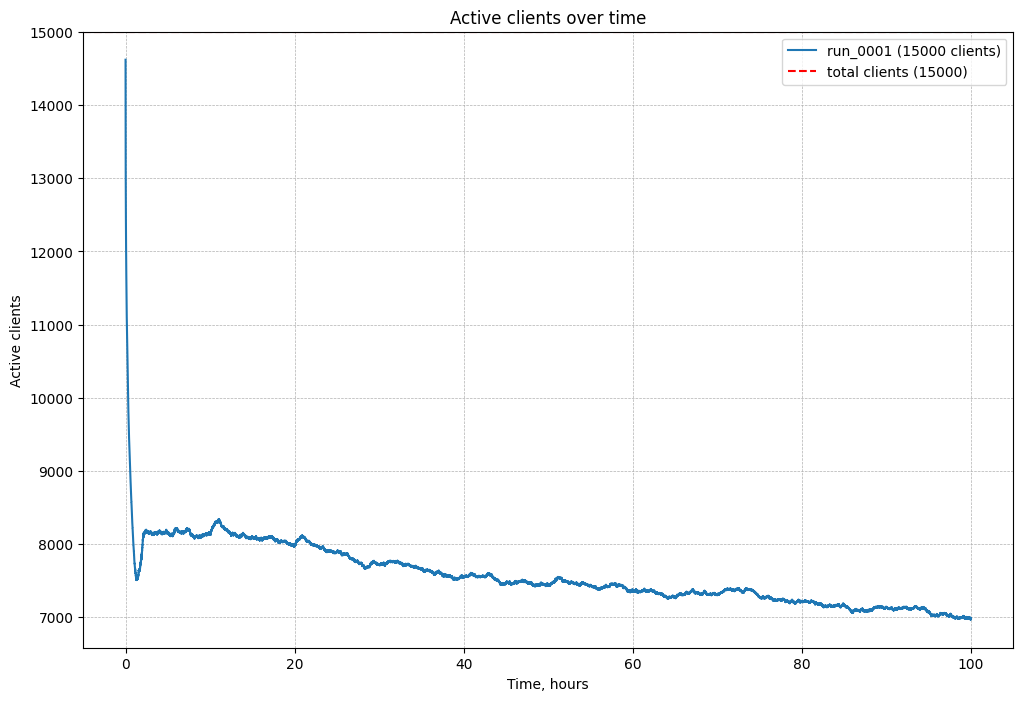

In [4]:
folders = sorted(
    f
    for f in os.listdir(STAT_PATH)
    if os.path.isdir(os.path.join(STAT_PATH, f)) and f.startswith(EXP_NAME)
)

if not folders:
    print(f"there is no folders in {STAT_PATH}")
else:
    print(f"found {folders}")

fig, ax = plt.subplots(figsize=(12, 8))

for folder in folders:
    full_path = os.path.join(STAT_PATH, folder)
    clients_dynamic_path = os.path.join(full_path, CLIENTS_DYNAMIC_NAME)

    if not os.path.exists(clients_dynamic_path):
        print(f"skip {folder}: {CLIENTS_DYNAMIC_NAME} not found")
        continue

    total_clients = None
    params_path = os.path.join(full_path, PARAMS_NAME)
    if os.path.exists(params_path):
        total_clients = read_total_clients(params_path)

    label = folder
    if total_clients is not None:
        label = f"{folder} ({total_clients} clients)"

    plot_active_clients(ax, clients_dynamic_path, label, total_clients)

ax.legend()
plt.show()
